shape: (135, 135)
symmetric: True
eigenvalues: min=2.427e-08, max=9.359e-05
positive definite: True


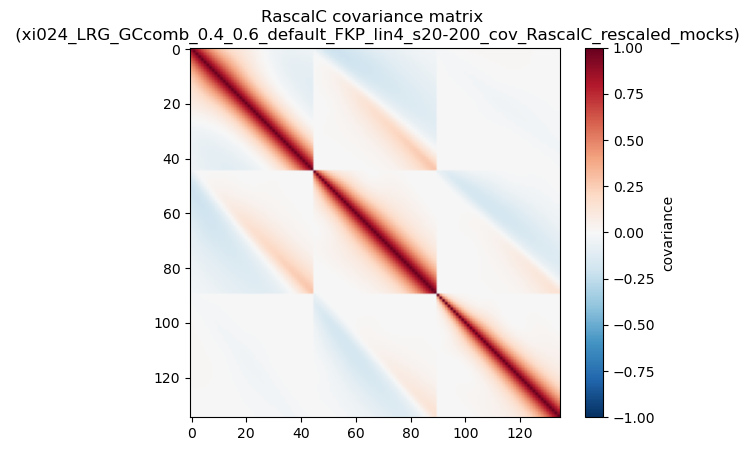

In [1]:
import numpy as np
import matplotlib.pyplot as plt

path = "/spiffball/cosweeney/mocks/AbacusSummit/covariances/dark/xi024_LRG_GCcomb_0.4_0.6_default_FKP_lin4_s20-200_cov_RascalC_rescaled_mocks.txt"  # <-- replace with your file

cov = np.loadtxt(path)  # '#' comment line is skipped automatically
print(f"shape: {cov.shape}")
print(f"symmetric: {np.allclose(cov, cov.T)}")

eigvals = np.linalg.eigvalsh(cov)
print(f"eigenvalues: min={eigvals.min():.3e}, max={eigvals.max():.3e}")
print(f"positive definite: {eigvals.min() > 0}")

diag = np.sqrt(np.diag(cov))
corr = cov / np.outer(diag, diag)

plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="covariance")
plt.title("RascalC covariance matrix \n (xi024_LRG_GCcomb_0.4_0.6_default_FKP_lin4_s20-200_cov_RascalC_rescaled_mocks)")
plt.show()

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = 'https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/mocks/AbacusSummit'
LOCAL_ROOT = Path('/spiffball/cosweeney/mocks/AbacusSummit')

import fitsio

from pycorr import TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging
from cosmoprimo.fiducial import DESI

setup_logging()
cosmo = DESI(engine='camb')

NRAN, NMOCK = 4, 25

# tracer key, program, z-bin, colour (eyedropped from the DESI DR1 figure)
SAMPLES = {
    'BGS':  ('BGS_BRIGHT-21.5', 'bright', (0.1, 0.4), '#8DC63F'),
    'LRG1': ('LRG',             'dark',   (0.4, 0.6), '#F5A623'),
    'LRG2': ('LRG',             'dark',   (0.6, 0.8), '#E8542A'),
    'LRG3': ('LRG',             'dark',   (0.8, 1.1), '#9E2B25'),
    'ELG':  ('ELG_LOPnotqso',   'dark',   (1.1, 1.6), '#2340D6'),
    'QSO':  ('QSO',             'dark',   (0.8, 2.1), '#4B8B5B'),
}

[000484.09]  09-02 22:32  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl0/LRG_GCcomb_z0.4-0.6_xismu.npy.
[000484.10]  09-02 22:32  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl1/LRG_GCcomb_z0.4-0.6_xismu.npy.
[000484.11]  09-02 22:32  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl2/LRG_GCcomb_z0.4-0.6_xismu.npy.
[000484.11]  09-02 22:32  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl3/LRG_GCcomb_z0.4-0.6_xismu.npy.
[000484.12]  09-02 22:32  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl4/LRG_GCcomb_z0.4-0.6_xismu.npy.
[000484.13]  09-02 22:32  TwoPointEstimator            INFO     Loading /spiffball/cosweeney/mocks/AbacusSummit/dark/altmtl5/LRG_GCcomb_z0.4-0.6_xismu.npy.
[000484.14]  09-02 22:32  TwoPointEstimator            INFO     

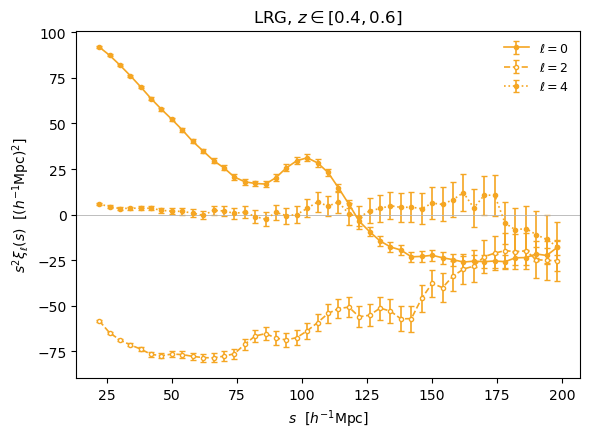

In [4]:
NBINS_COV, NELLS_COV = 45, 3
SREBIN = 4
SRANGE = (20., 200.)

tracer, prog, (zmin, zmax), colour = SAMPLES['LRG1']

def load_poles_matched(tracer, prog, zmin, zmax, ells=(0, 2, 4)):
    """Return s and array of shape (nmock, nells, nbins), rebinned/selected to match the covariance."""
    s, out = None, []
    for i in range(NMOCK):
        p = (LOCAL_ROOT / prog / f'altmtl{i}' /
             f'{tracer}_GCcomb_z{zmin}-{zmax}_xismu.npy')
        if not p.exists():
            continue
        r = TwoPointCorrelationFunction.load(p)[::SREBIN].select(SRANGE)
        s, poles = r(ells=ells, return_sep=True)
        out.append(poles)
    return s, np.array(out)

s, poles = load_poles_matched(tracer, prog, zmin, zmax)
mean = poles.mean(axis=0)  # shape (3, 45)

assert mean.shape[-1] == NBINS_COV, f"bin mismatch: got {mean.shape[-1]}, covariance has {NBINS_COV}"

# diagonal blocks of cov, ordered ell=0,2,4 (standard RascalC convention — see note above)
sigma = np.sqrt(np.diag(cov)).reshape(NELLS_COV, NBINS_COV) / 5 # account for avg over 25 mocks

fig, ax = plt.subplots(figsize=(6, 4.5))
labels = [r'$\ell=0$', r'$\ell=2$', r'$\ell=4$']
mfc = [colour, 'white', colour]
ls = ['-', '--', ':']

for i, (lbl, fc, style) in enumerate(zip(labels, mfc, ls)):
    ax.errorbar(s, s**2 * mean[i], s**2 * sigma[i], color=colour,
                marker='o', ms=3, lw=1.2, ls=style, capsize=2,
                mfc=fc, label=lbl)

ax.axhline(0, color='0.7', lw=0.6)
ax.set_xlabel(r'$s$  $[h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'$s^2\xi_\ell(s)$  $[(h^{-1}\mathrm{Mpc})^2]$')
ax.set_title(r'LRG, $z\in[0.4,0.6]$')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()